In [8]:
!!pip uninstall numpy scipy shap -y

['Found existing installation: numpy 1.26.4',
 'Uninstalling numpy-1.26.4:',
 '  Successfully uninstalled numpy-1.26.4',
 "WARNING: Failed to remove contents in a temporary directory 'F:\\anaconda3\\envs\\demand-predictor\\Lib\\site-packages\\~0mpy.libs'.",
 'You can safely remove it manually.',
 "WARNING: Failed to remove contents in a temporary directory 'F:\\anaconda3\\envs\\demand-predictor\\Lib\\site-packages\\~0mpy'.",
 'You can safely remove it manually.',
 'Found existing installation: scipy 1.11.4',
 'Uninstalling scipy-1.11.4:',
 '  Successfully uninstalled scipy-1.11.4',
 "WARNING: Failed to remove contents in a temporary directory 'F:\\anaconda3\\envs\\demand-predictor\\Lib\\site-packages\\~0ipy.libs'.",
 'You can safely remove it manually.',
 "WARNING: Failed to remove contents in a temporary directory 'F:\\anaconda3\\envs\\demand-predictor\\Lib\\site-packages\\~0ipy'.",
 'You can safely remove it manually.',
 'Found existing installation: shap 0.44.1',
 'Uninstalling shap

In [9]:
!pip install numpy==1.26.4 scipy==1.11.4 shap==0.44.1

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached scipy-1.11.4-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached shap-0.44.1-cp311-cp311-win_amd64.whl.metadata (25 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
Using cached scipy-1.11.4-cp311-cp311-win_amd64.whl (44.1 MB)
Using cached shap-0.44.1-cp311-cp311-win_amd64.whl (450 kB)

   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ----------------------------------------

In [10]:
import sys
!{sys.executable} -m pip install optuna

In [11]:
!pip uninstall torch torchvision torchaudio -y

In [12]:
# ── Cell 1 — imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import optuna
import pickle
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import mlflow

print("All imports done!")

All imports done!


In [13]:
# ── Cell 2 — load data and model ─────────────────────────────────────
ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df_fixed.csv')
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

with open('models/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

with open('models/lgbm_v1.pkl', 'rb') as f:
    model_v1 = pickle.load(f)

X = ts_df[FEATURE_COLS]
y = ts_df['demand']

cutoff     = ts_df['datetime'].max() - pd.Timedelta(weeks=4)
train_mask = ts_df['datetime'] <= cutoff
val_mask   = ts_df['datetime'] >  cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Train : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Features: {len(FEATURE_COLS)}")

Train : 1,658,686
Val   : 316,852
Features: 32


In [14]:
# ── Cell 3 — evaluation helper ────────────────────────────────────────
def evaluate(y_true, y_pred, name="model"):
    nonzero = y_true > 0
    y_nz    = np.array(y_true)[nonzero]
    p_nz    = np.array(y_pred)[nonzero]

    mape = np.mean(np.abs((y_nz - p_nz) / y_nz)) * 100
    wape = np.sum(np.abs(y_nz - p_nz)) / np.sum(y_nz) * 100
    rmse = np.sqrt(mean_squared_error(y_nz, p_nz))
    r2   = r2_score(y_nz, p_nz)
    bias = np.mean(p_nz - y_nz)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  WAPE : {wape:.2f}%")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  Bias : {bias:.4f}")
    print(f"{'='*45}")

    return {'model':name,'mape':round(mape,2),'wape':round(wape,2),
            'rmse':round(rmse,2),'r2':round(r2,4),'bias':round(bias,4)}

In [15]:
# ── Cell 4 — use sample for Optuna (speed) ────────────────────────────
# 2M rows x 50 trials would take hours
# sample 30% of training data — still 600k rows, statistically valid

sample_frac  = 0.30
train_sample = X_train.sample(frac=sample_frac, random_state=42)
y_sample     = y_train.loc[train_sample.index]

print(f"Full train size   : {X_train.shape[0]:,}")
print(f"Sample train size : {train_sample.shape[0]:,}")
print(f"Val size          : {X_val.shape[0]:,}")
print("Using sample for Optuna speed — final model trains on full data")

Full train size   : 1,658,686
Sample train size : 497,606
Val size          : 316,852
Using sample for Optuna speed — final model trains on full data


In [16]:
!pip uninstall lightgbm -y
!pip install lightgbm --config-settings=cmake.define.USE_GPU=ON

Found existing installation: lightgbm 4.6.0
Uninstalling lightgbm-4.6.0:
  Successfully uninstalled lightgbm-4.6.0


You can safely remove it manually.


  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [17]:
import lightgbm as lgb

print(lgb.__version__)

4.6.0


In [18]:
import lightgbm as lgb

model = lgb.LGBMRegressor(device='gpu')
print("GPU enabled")

GPU enabled


In [19]:
# ── Cell 5 — Optuna objective function ───────────────────────────────
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.0, 1.0),
           # GPU SETTINGS

        
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        train_sample, y_sample,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(999)]
    )

    pred    = np.clip(model.predict(X_val), 0, None)
    nonzero = y_val > 0
    y_nz    = y_val[nonzero].values
    p_nz    = pred[nonzero]
    wape    = np.sum(np.abs(y_nz - p_nz)) / np.sum(y_nz) * 100

    return wape  # minimize WAPE

print("Objective function defined")
print("Optimizing WAPE — lower is better")

Objective function defined
Optimizing WAPE — lower is better


In [20]:
# ── Cell 6 — run Optuna (50 trials ~10-15 mins) ───────────────────────
study = optuna.create_study(
    direction  = "minimize",
    study_name = "demand-pulse-lgbm",
    sampler    = optuna.samplers.TPESampler(seed=42)
)

print("Starting Optuna — 50 trials...")
print("Each trial takes ~15-20 seconds. Total ~15 mins.\n")

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest WAPE  : {study.best_value:.2f}%")
print(f"Best params: {study.best_params}")

Starting Optuna — 50 trials...
Each trial takes ~15-20 seconds. Total ~15 mins.



  0%|          | 0/50 [00:00<?, ?it/s]


Best WAPE  : 7.88%
Best params: {'n_estimators': 326, 'learning_rate': 0.04934856670193974, 'max_depth': 11, 'num_leaves': 191, 'min_child_samples': 56, 'subsample': 0.8157587408685801, 'colsample_bytree': 0.8499572810083845, 'reg_alpha': 0.6092599562105124, 'reg_lambda': 0.3514870513111851}


In [21]:
# ── Cell 7 — train final model on full data with best params ──────────
best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

print("Training final model on FULL training data with best params...")
print(f"Params: {best_params}\n")

mlflow.set_experiment("demand-pulse")

with mlflow.start_run(run_name="lgbm_v2_optuna"):
    model_v2 = lgb.LGBMRegressor(**best_params)
    model_v2.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(100)]
    )

    pred_v2   = np.clip(model_v2.predict(X_val), 0, None)
    metrics_v2 = evaluate(y_val.values, pred_v2, "LightGBM v2 (Optuna tuned)")

    mlflow.log_params(best_params)
    mlflow.log_metric("mape", metrics_v2['mape'])
    mlflow.log_metric("wape", metrics_v2['wape'])
    mlflow.log_metric("rmse", metrics_v2['rmse'])
    mlflow.log_metric("r2",   metrics_v2['r2'])
    mlflow.sklearn.log_model(model_v2, "lgbm_v2")

print("Training done!")

Training final model on FULL training data with best params...
Params: {'n_estimators': 326, 'learning_rate': 0.04934856670193974, 'max_depth': 11, 'num_leaves': 191, 'min_child_samples': 56, 'subsample': 0.8157587408685801, 'colsample_bytree': 0.8499572810083845, 'reg_alpha': 0.6092599562105124, 'reg_lambda': 0.3514870513111851, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

[100]	valid_0's l2: 0.129892

  LightGBM v2 (Optuna tuned)
  MAPE : 11.02%
  WAPE : 7.89%
  RMSE : 0.36
  R²   : 0.9386
  Bias : -0.0482
Training done!


In [22]:
# ── Cell 8 — compare v1 vs v2 ─────────────────────────────────────────
pred_v1   = np.clip(model_v1.predict(X_val), 0, None)
metrics_v1 = evaluate(y_val.values, pred_v1, "LightGBM v1 (default)")

results = pd.DataFrame([metrics_v1, metrics_v2])
print("\nComparison:")
print(results[['model','mape','wape','rmse','r2','bias']].to_string(index=False))

improvement = metrics_v1['wape'] - metrics_v2['wape']
print(f"\nOptuna improved WAPE by {improvement:.2f}%")


  LightGBM v1 (default)
  MAPE : 11.38%
  WAPE : 8.36%
  RMSE : 0.37
  R²   : 0.9356
  Bias : -0.0621

Comparison:
                     model  mape  wape  rmse     r2    bias
     LightGBM v1 (default) 11.38  8.36  0.37 0.9356 -0.0621
LightGBM v2 (Optuna tuned) 11.02  7.89  0.36 0.9386 -0.0482

Optuna improved WAPE by 0.47%


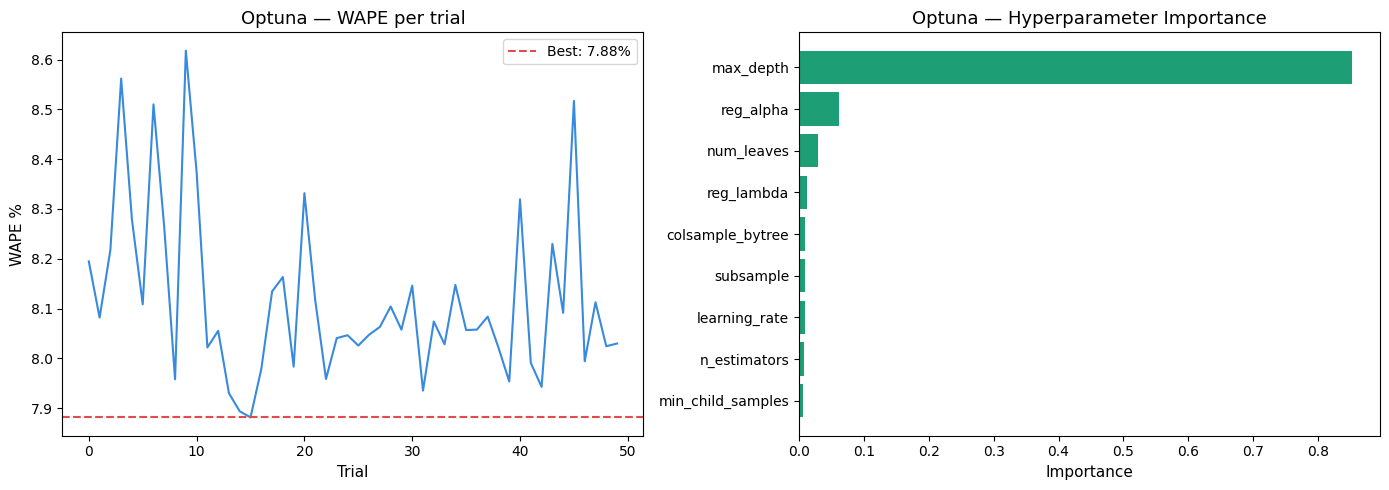

Saved optuna results plot!


In [23]:
# ── Cell 9 — Optuna optimization history plot ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# trial values over time
values = [t.value for t in study.trials]
axes[0].plot(values, color='#378ADD', linewidth=1.5)
axes[0].axhline(y=study.best_value, color='#E24B4A',
                linestyle='--', label=f'Best: {study.best_value:.2f}%')
axes[0].set_title('Optuna — WAPE per trial', fontsize=13)
axes[0].set_xlabel('Trial', fontsize=11)
axes[0].set_ylabel('WAPE %', fontsize=11)
axes[0].legend()

# parameter importance
param_importance = optuna.importance.get_param_importances(study)
params = list(param_importance.keys())
importances = list(param_importance.values())
axes[1].barh(params[::-1], importances[::-1], color='#1D9E75', edgecolor='none')
axes[1].set_title('Optuna — Hyperparameter Importance', fontsize=13)
axes[1].set_xlabel('Importance', fontsize=11)

plt.tight_layout()
plt.savefig('plot_optuna_results.png', dpi=150)
plt.show()
print("Saved optuna results plot!")

In [24]:
# ── Cell 10 — SHAP explainability ────────────────────────────────────
# use 2000 row sample for speed — SHAP is slow on large datasets
print("Computing SHAP values (this takes 2-3 mins)...")

shap_sample = X_val.sample(2000, random_state=42)

explainer   = shap.TreeExplainer(model_v2)
shap_values = explainer.shap_values(shap_sample)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("Done!")

Computing SHAP values (this takes 2-3 mins)...
SHAP values shape: (2000, 32)
Done!


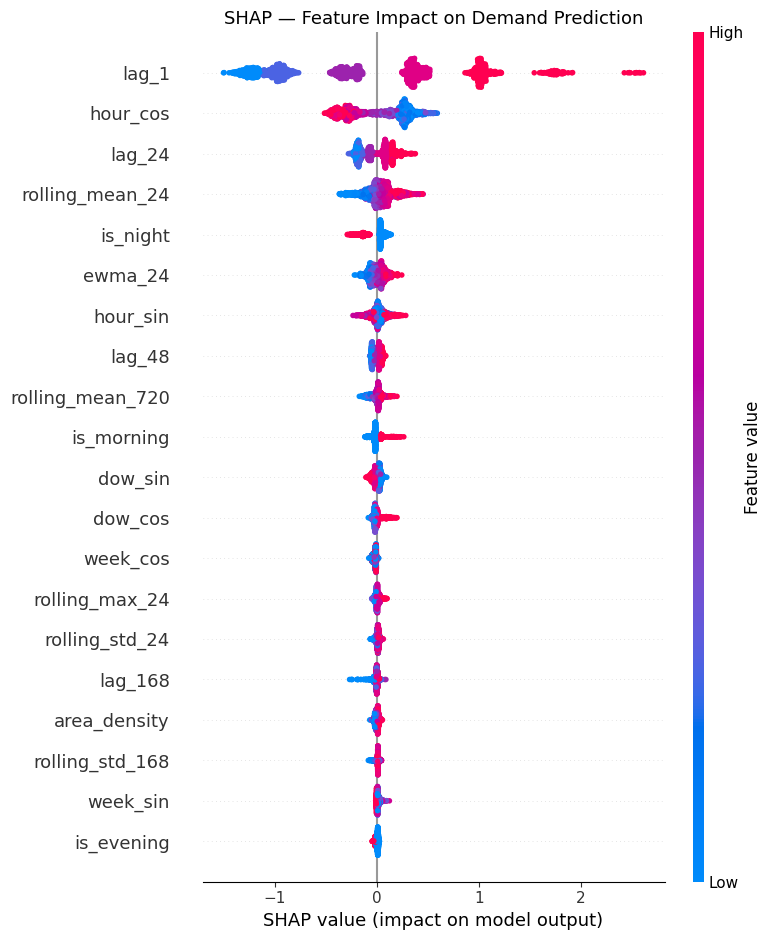

Saved SHAP beeswarm plot — put this in your README!


In [25]:
# ── Cell 11 — SHAP beeswarm plot (most important for CV/README) ───────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, shap_sample,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP — Feature Impact on Demand Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('plot_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved SHAP beeswarm plot — put this in your README!")

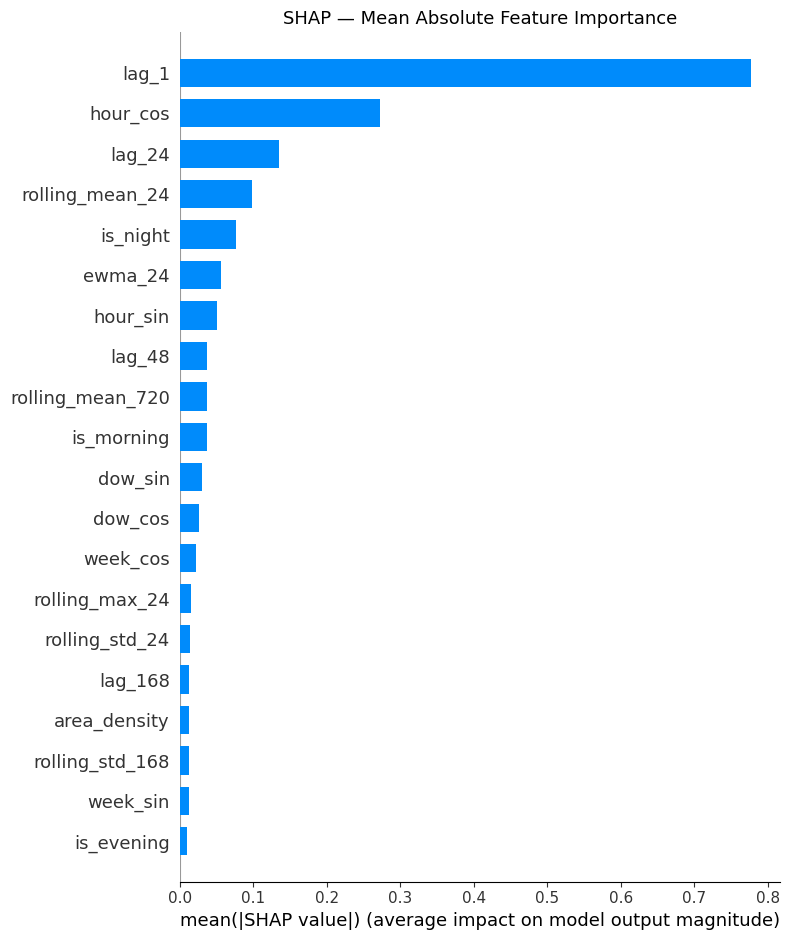

In [26]:
# ── Cell 12 — SHAP bar plot (mean absolute impact) ───────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, shap_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP — Mean Absolute Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig('plot_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

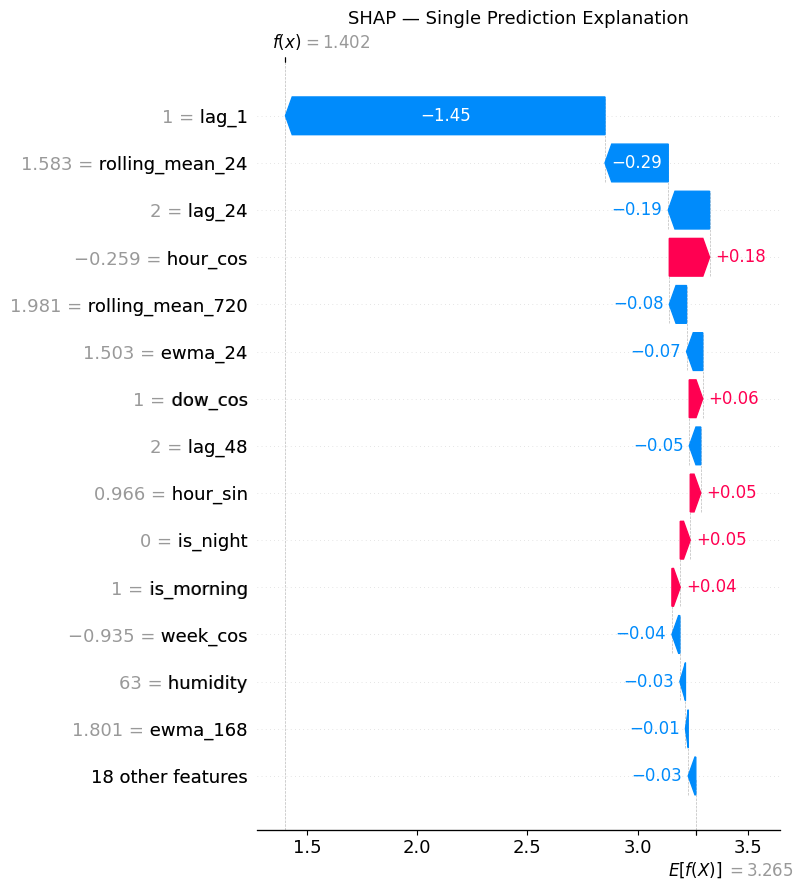

Saved waterfall plot!


In [27]:
# ── Cell 13 — SHAP waterfall for single prediction ────────────────────
# explains one specific prediction — good for demos
shap_explanation = explainer(shap_sample.iloc[:1])

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation[0], max_display=15, show=False)
plt.title('SHAP — Single Prediction Explanation', fontsize=13)
plt.tight_layout()
plt.savefig('plot_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved waterfall plot!")

In [28]:
# ── Cell 14 — error analysis by product ──────────────────────────────
val_df = ts_df[val_mask].copy()
val_df['predicted'] = pred_v2
val_df['error']     = np.abs(val_df['demand'] - val_df['predicted'])
val_df['pct_error'] = val_df['error'] / val_df['demand'].replace(0, np.nan) * 100

product_errors = (val_df.groupby('product_name')
                  .agg(mean_demand=('demand','mean'),
                       mean_error=('pct_error','mean'))
                  .dropna()
                  .sort_values('mean_error')
                  .reset_index())

print("Top 10 best predicted products:")
print(product_errors.head(10).to_string(index=False))
print("\nTop 10 worst predicted products:")
print(product_errors.tail(10).to_string(index=False))

Top 10 best predicted products:
          product_name  mean_demand  mean_error
                Banana     4.638621    6.565879
Bag of Organic Bananas     4.467470    6.588040
  Organic Strawberries     4.178550    7.158043
  Organic Baby Spinach     4.080811    7.336018
  Organic Hass Avocado     3.983925    7.462121
       Organic Avocado     3.771713    8.594013
   Organic Raspberries     3.584926    8.869395
          Strawberries     3.613971    8.960585
                 Limes     3.556169    9.057509
           Large Lemon     3.631385    9.349704

Top 10 worst predicted products:
                   product_name  mean_demand  mean_error
     Organic Small Bunch Celery     3.047839   12.314382
Organic Unsweetened Almond Milk     2.937174   12.389804
                      Asparagus     3.048003   12.417117
        Organic Red Bell Pepper     2.938272   12.439830
          Michigan Organic Kale     3.029936   12.461792
         100% Whole Wheat Bread     2.962915   12.526737
    Org

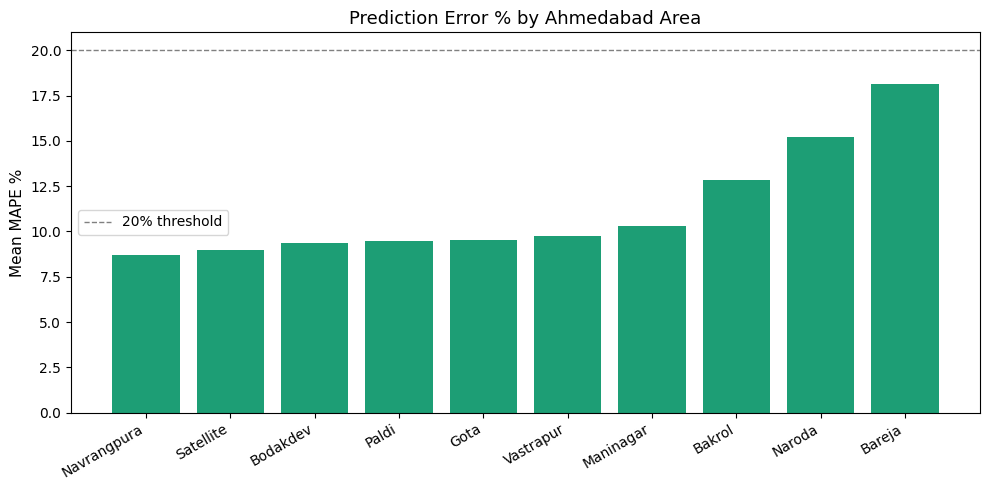


Error by area:
  area_name  mean_demand  mean_error
Navrangpura     3.914719    8.689591
  Satellite     3.875899    8.957842
   Bodakdev     3.774218    9.370706
      Paldi     3.714105    9.457109
       Gota     3.608686    9.539308
  Vastrapur     3.454764    9.749666
  Maninagar     3.289668   10.281787
     Bakrol     2.609400   12.860394
     Naroda     2.334472   15.236889
     Bareja     1.892749   18.144619


In [29]:
# ── Cell 15 — error analysis by pincode ──────────────────────────────
pincode_errors = (val_df.groupby('area_name')
                  .agg(mean_demand=('demand','mean'),
                       mean_error=('pct_error','mean'))
                  .dropna()
                  .sort_values('mean_error')
                  .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#1D9E75' if e < 20 else '#E24B4A'
           for e in pincode_errors['mean_error']]
ax.bar(pincode_errors['area_name'],
       pincode_errors['mean_error'],
       color=colors, edgecolor='none')
ax.axhline(y=20, color='gray', linestyle='--',
           linewidth=1, label='20% threshold')
ax.set_title('Prediction Error % by Ahmedabad Area', fontsize=13)
ax.set_ylabel('Mean MAPE %', fontsize=11)
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot_error_by_pincode.png', dpi=150)
plt.show()

print("\nError by area:")
print(pincode_errors.to_string(index=False))

In [30]:
# ── Cell 16 — save best model and results ────────────────────────────
with open('models/lgbm_best.pkl', 'wb') as f:
    pickle.dump(model_v2, f)

with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

final_results = pd.DataFrame([metrics_v1, metrics_v2])
final_results.to_csv(r'F:\projectss\personal\blinkit_project\data\processed/model_results_final.csv', index=False)

print("Saved:")
print("  models/lgbm_best.pkl       ← use this for deployment")
print("  models/feature_cols.pkl")
print("  data/processed/model_results_final.csv")
print("\nNotebook 04 complete — ready for deployment!")

Saved:
  models/lgbm_best.pkl       ← use this for deployment
  models/feature_cols.pkl
  data/processed/model_results_final.csv

Notebook 04 complete — ready for deployment!


In [31]:
import pickle
import pandas as pd

with open('models/lgbm_best.pkl', 'rb') as f:
    model = pickle.load(f)

with open('models/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

selected = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\external\selected_ahmedabad_pincodes.csv')

print("Model loaded    :", type(model))
print("Features count  :", len(FEATURE_COLS))
print("Pincode file    :")
print(selected.head(3))
print("\nColumns in pincode file:", selected.columns.tolist())

Model loaded    : <class 'lightgbm.sklearn.LGBMRegressor'>
Features count  : 32
Pincode file    :
   pincode    area_name   latitude  longitude
0   380009  Navrangpura  23.047151  72.552753
1   380015    Satellite  23.026800  72.523330
2   380051     Bodakdev  23.004847  72.520865

Columns in pincode file: ['pincode', 'area_name', 'latitude', 'longitude']


In [32]:
pincode_df=pd.read_csv(r'F:\projectss\personal\blinkit_project\data\5c2f62fe-5afa-4119-a499-fec9d604d5bd.csv')

In [ ]:
'''# run this in notebook 01 — add as a new cell at the bottom

ahmedabad_df = pincode_df[
    pincode_df['district'].str.upper().str.contains('AHMADABAD', na=False)
].copy()

ahmedabad_df = ahmedabad_df.dropna(subset=['latitude','longitude'])
ahmedabad_df = ahmedabad_df.drop_duplicates(subset='pincode')

# pick top 10
selected = ahmedabad_df[
    ['pincode','officename','district','latitude','longitude']
].head(10).reset_index(drop=True)

# clean area name
selected = selected.rename(columns={'officename':'area_name'})
selected['area_name'] = selected['area_name'].str.replace(
    r'\s*(S\.O|B\.O|H\.O|BO|SO|HO)$', '', regex=True
).str.strip().str.title()

print("Selected 10 Ahmedabad pincodes:")
print(selected)
print("\nColumns:", selected.columns.tolist())

# save
selected.to_csv(r'F:\projectss\personal\blinkit_project\data\external/selected_ahmedabad_pincodes.csv', index=False)
print("\nSaved → data/external/selected_ahmedabad_pincodes.csv")'''

Selected 10 Ahmedabad pincodes:
   pincode  area_name   district    latitude   longitude
0   382210     Bakrol  AHMADABAD   23.029651   72.626689
1   382430  Kubadthal  AHMADABAD   23.033567   72.758744
2   382330    Pardhol  AHMADABAD   23.095606   72.726643
3   382425   Girmatha  AHMADABAD   22.877825   72.551355
4   382435   Geratpur  AHMADABAD   22.920627   72.648634
5   382225     Vautha  AHMADABAD  22.6700000  72.5400000
6   382220     Adroda  AHMADABAD  22.8300000  72.3100000
7   382463      Ambli  AHMADABAD  23.0300000  72.4800000
8   382260  Chandisar  AHMADABAD  22.8000000  72.4900000
9   382460     Jaliya  AHMADABAD  22.7300000  72.4800000

Columns: ['pincode', 'area_name', 'district', 'latitude', 'longitude']

Saved → data/external/selected_ahmedabad_pincodes.csv
